<a href="https://colab.research.google.com/github/Sujal9858/SujalGit/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Supervised Learning: Binary Classifiers Template
#Glen Mason
#Week 4 Support Vector Classifier

In [2]:
#Declare Reference to General Libraries
import pandas as pd #Used to manipulate data sets (derived from PaNel DAta) pd is a short alias.
import numpy as np #Used to work with Arrays (e.g. useful in manual I/O validation)
import matplotlib.pyplot as plt #Used to generate statistical illustrations e.g. graphs
import seaborn as sns #A more sophisticated version of matplotlib
#Import Special Data Analysis Packages
from sklearn.model_selection import train_test_split #Used to split Data Set
from sklearn.svm import SVC #Selected Modelling Algorithim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Rows Columns
(569, 31)
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  radius_se  texture_se  perimeter_se  area

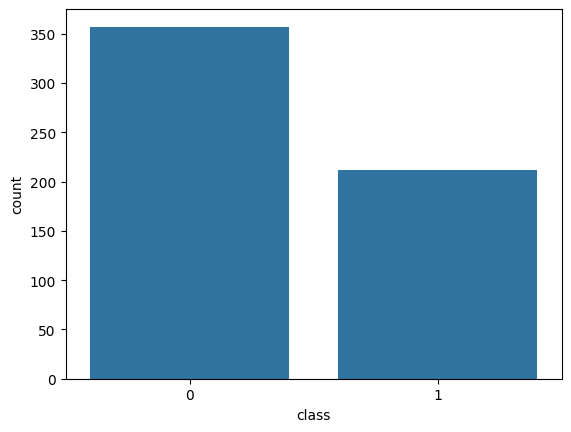

<Figure size 640x480 with 0 Axes>

In [5]:
#Read and Display Data Set
#First, read in CSV file and assign it to a variable called "data"
data = pd.read_csv('breast_cancer_diagnosis.csv')
#Second, display maximum rows and columns
print('\nRows Columns') #indicates rows and columns
print(data.shape) #gets the number rows and columns of data
pd.set_option('display.max_columns',None) #optional setting to show all feature columns
#Third, display first 5 x rows to check data
print(data.head(5))
#Select the last column (assuming the last column is the class)
last_column = data.iloc[:, -1] # Using iloc to select the last column
#Count occurrences of 0's and 1's
value_counts = last_column.value_counts()
#Print the counts and check for class imbalance
print('\n',value_counts)
#------EXTRA DATA SCIENCE INFO--------
#Display grahical Bar Chart of classification balance
sns.countplot(x='class', data=data)
plt.show()
plt.clf()


Axes(0.125,0.11;0.62x0.77)


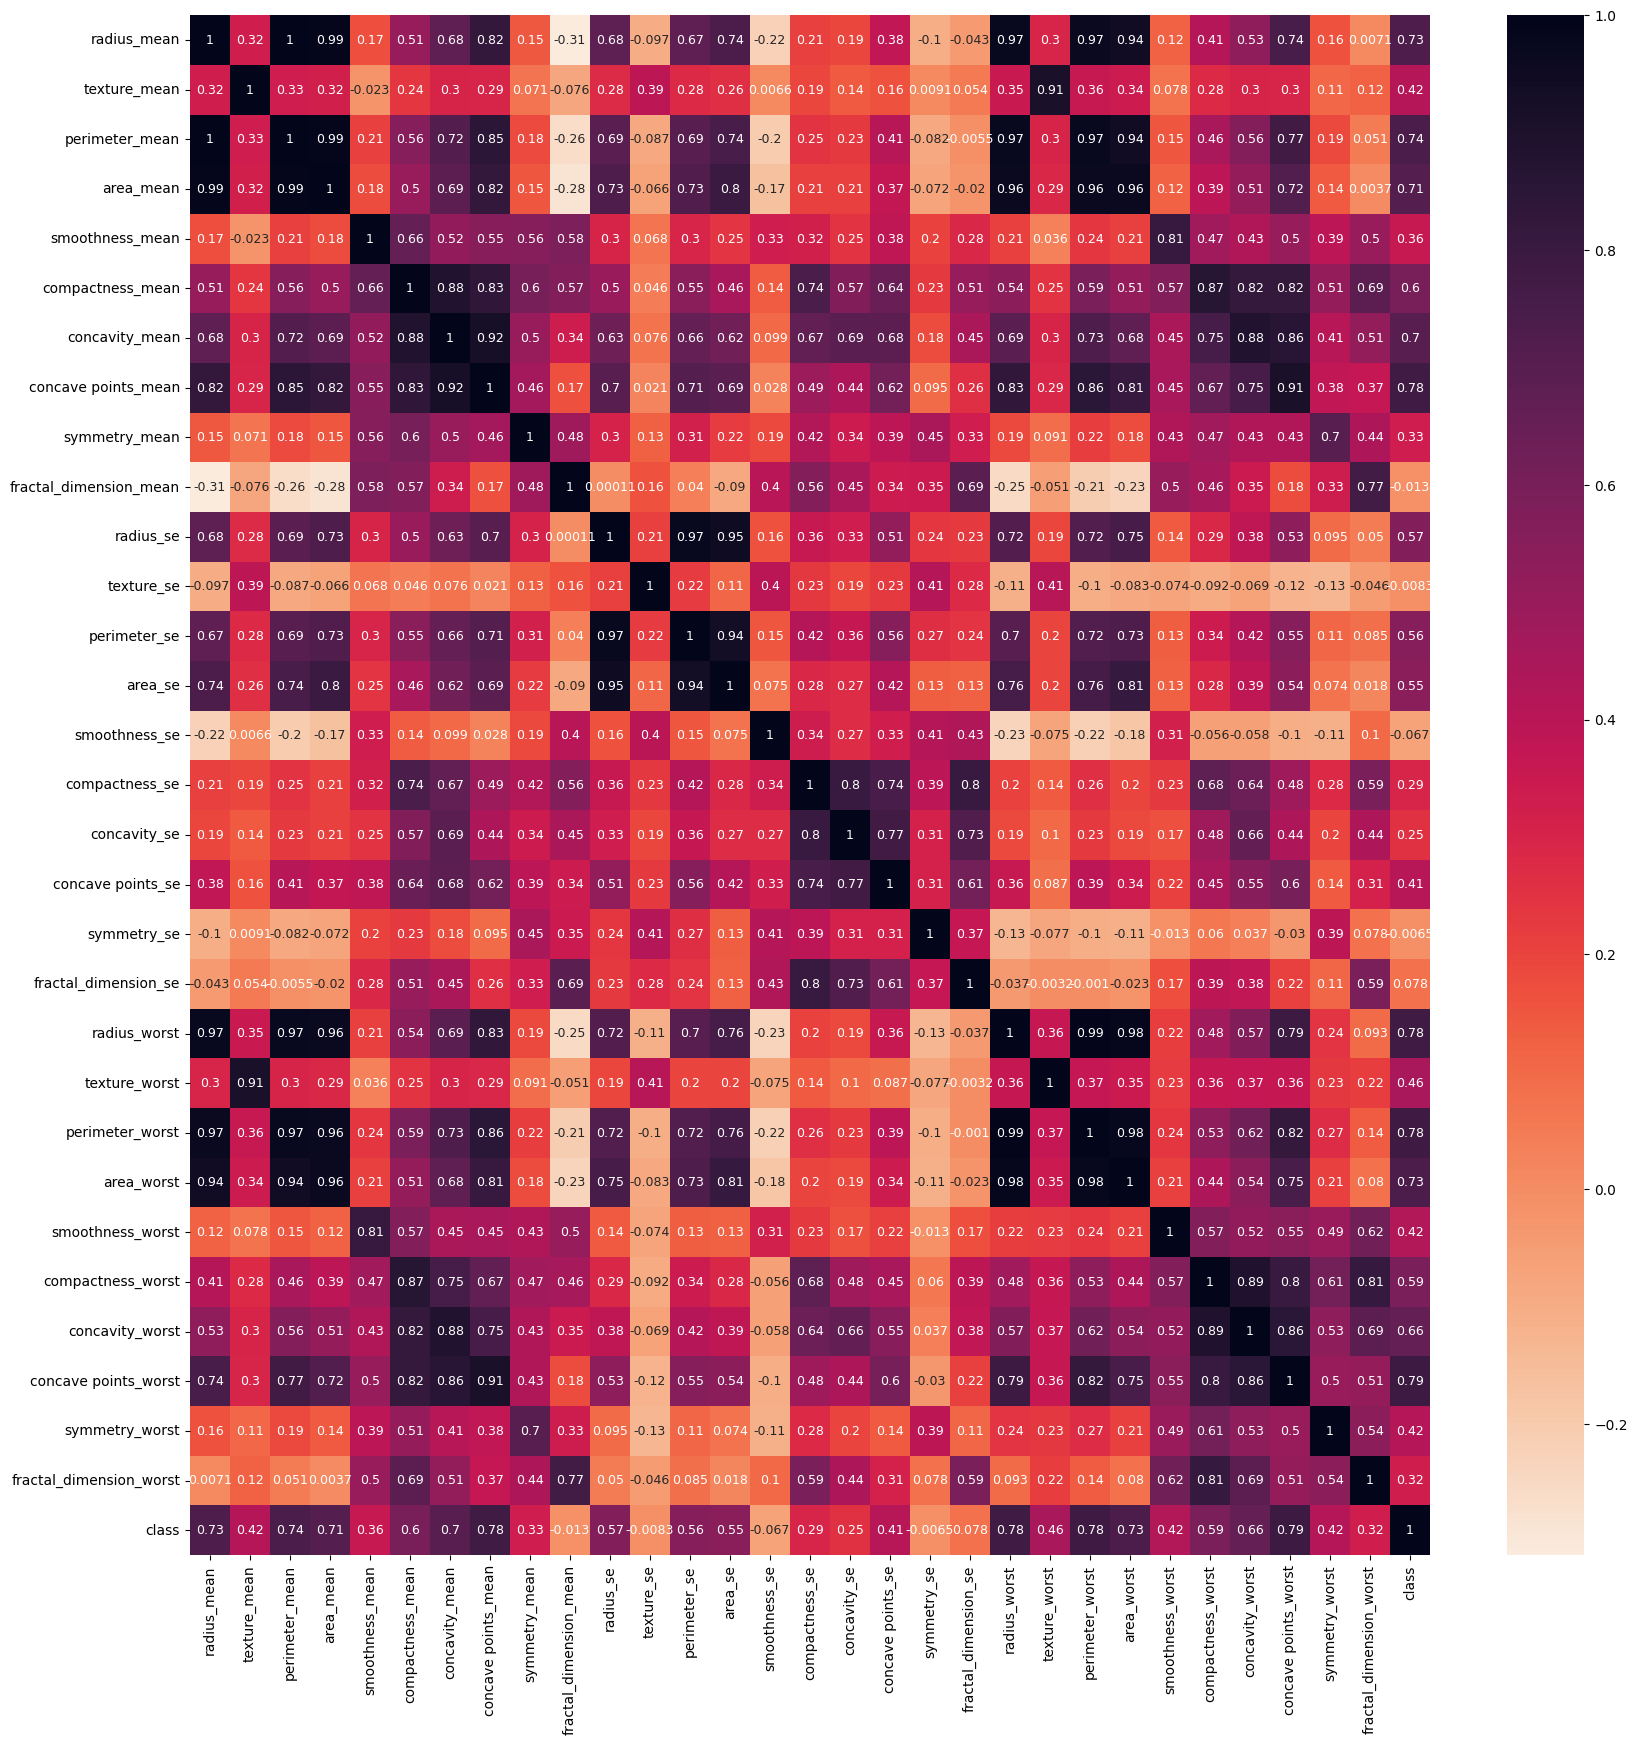

In [6]:
#Display Feature Relations of Data Set
plt.figure(figsize=(20,20)) #Adjust width and height
print(sns.heatmap(data.corr(),annot=True, annot_kws={"size":9}, cmap = sns.cm.rocket_r))


In [7]:
#Declare X and Y Variables and Split the DataSet into Train and Test sections
X=data.drop(['class'],axis=1).values #X variables = all columns except last one
#Declare last column to be the dependednt Y variable
y=data['class']
#Split Data Set 70% Training and 30% Testing. Initial data shuffle set to Zero.
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size = 0.3, random_state=0)


In [8]:
#Create and Test the Model
#First declare a new model
classifier_model = SVC(C=10,gamma=0.01)
#Second Train (fit) the model from the training data
classifier_model.fit(X_train,y_train)
#Fourth make some predictions
y_pred = classifier_model.predict(X_test)
print('\nTest Data Model Predictions',y_pred)



Test Data Model Predictions [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [10]:
#Evaluate the Model: Display Confusion Matrix and Performance Metrics
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Display the performance metrics
print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")



Confusion Matrix:
 [[107   1]
 [ 62   1]]

Evaluation Metrics:
Accuracy: 0.63
Precision: 0.50
Recall: 0.02
F1 Score: 0.03


In [11]:
#Optimising the Model for better metrics
from sklearn.model_selection import GridSearchCV
param_grid = {'C':[0.1,1,10,100,1000],'gamma':[1,0.1,0.01,0.001,0.0001]}
grid = GridSearchCV(SVC(),param_grid,verbose=3)
grid.fit(X_train,y_train)
grid.best_params_
grid_predictions = grid.predict(X_test)
#Display best parameters
print("\n Optimised Parameters: ")
print(grid.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.625 total time=   0.0s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.625 total time=   0.0s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.625 total time=   0.0s
[CV 4/5] END ....................C=0.1, gamma=1;, score=0.633 total time=   0.0s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.620 total time=   0.0s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.625 total time=   0.0s
[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.625 total time=   0.0s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.625 total time=   0.0s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.633 total time=   0.0s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.620 total time=   0.0s
[CV 1/5] END .................C=0.1, gamma=0.01;, score=0.625 total time=   0.0s
[CV 2/5] END .................C=0.1, gamma=0.01